# Multi-Session PCA Analysis - Class Usage

This notebook demonstrates the `MultiSessionPCA` class for clean, modular PCA analysis.

**Benefits over the original notebook:**
- Clean, reusable code
- Easy parameter tuning
- Simple workflow for rolling window analysis
- All functionality in one place

**Quick Start:**
```python
analyzer = MultiSessionPCA(config)
analyzer.load_data(pickle_path)
analyzer.validate_all_sessions()
analyzer.extract_all_sessions_parallel()
analyzer.concatenate_sessions()
analyzer.subtract_average()
analyzer.fit_and_project()
analyzer.plot_3d_trajectory()
analyzer.save_results('output/')
```

In [2]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from pprint import pprint

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import the class
import importlib
import session_class
importlib.reload(session_class)
from session_class import Session

# Also reload multi_session_pca if needed
import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## Example 1: Basic Usage with Default Configuration

In [3]:
# Initialize with default configuration
analyzer = MultiSessionPCA({
    'epok': [-100, 200],
    'bin_size': 1,
    'smooth_ker_size': 25,
    'alignment_point': 'go_cue',
    'ssd_number': 2,
    'normalize': False,
    'delta': True,
    'subtract_average': False
})

# Check default config
print("Default Configuration:")
pprint(analyzer.config)

Default Configuration:
{'alignment_point': 'go_cue',
 'bin_size': 1,
 'delta': True,
 'epok': [-100, 200],
 'excluded_sessions': ['fi210628', 'fi210629', 'fi210704'],
 'figsize_2d_grid': (7, 19),
 'figsize_3d': (12, 10),
 'figsize_time': (10, 3),
 'min_cells_per_session': 10,
 'min_trials_per_condition': 5,
 'monkey': 'fiona',
 'n_pca_components': 5,
 'n_workers': 6,
 'normalize': False,
 'required_directions': [0, 180],
 'required_trial_types': ['GO', 'STOP', 'CONT'],
 'smooth_ker_size': 25,
 'ssd_number': 2,
 'subtract_average': False}


In [4]:
# Load data
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

analyzer.load_data(pickle_file)

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414


In [5]:
# Validate sessions
analyzer.validate_all_sessions(verbose=True)

✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Validating sessions...
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi211018a: Valid (40 cells)
✓ fi211123a: Valid (36 cells)
✓ fi211019a: Valid (34 cells)
✓ fi211125a: Valid (34 cells)
✓ fi211014a: Valid (32 cells)
✓ fi211017a: Valid (32 cells)
✓ fi211103a: Valid (29 cells)
✓ fi211021a: Valid (27 cells)
✓ fi211124a: Valid (26 cells)
✓ fi210907a: Valid (25 cells)
✓ fi210909a: Valid (23 cells)
✓ fi211

In [6]:
# Extract PSTH matrices (parallel processing)
sessions_PSTHs = analyzer.extract_all_sessions_parallel(pickle_path=pickle_file)

Extracting PSTHs from 40 sessions using 6 workers...
  Using pre-loaded data (efficient mode)
  Subtract average: False
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


Processing:   5%|▌         | 2/40 [00:02<00:36,  1.04it/s]

[1/40] ✓ fi211102a: 71 cells
[2/40] ✓ fi211026a: 75 cells (dropped 1 with no STOP ssd=2)


Processing:   8%|▊         | 3/40 [00:02<00:23,  1.56it/s]

[3/40] ✓ fi211025a: 63 cells


...

Processing:  90%|█████████ | 36/40 [00:10<00:00,  9.47it/s]

[34/40] ✓ fi210812a: 13 cells
[35/40] ✓ fi210727a: 12 cells (dropped 1 with no STOP ssd=2)
[36/40] ✓ fi210726a: 11 cells
[37/40] ✓ fi210901a: 12 cells
[38/40] ✓ fi210721a: 12 cells


Processing: 100%|██████████| 40/40 [00:10<00:00,  3.68it/s]

[39/40] ✓ fi210815a: 11 cells
[40/40] ✓ fi210809a: 10 cells


--------------------------------------------------------------------------------
✓ Extraction complete: 40/40 successful
  ⚠ SSD filtering: 4/1322 cells dropped (0.3%)
  Cells retained: 1318


In [7]:
# Prepare data for PCA
analyzer.concatenate_sessions()
# analyzer.subtract_average_PSTH()

Concatenating PSTH matrices across sessions...
✓ Concatenation complete:
  GO Left: (1318, 300)
  GO Right: (1318, 300)
  STOP Left: (1318, 300)
  STOP Right: (1318, 300)


In [8]:
analyzer.fit_pca(pca_type='TruncatedSVD')
analyzer.project_all_conditions()

✓ PCA matrix prepared: (1318, 600)
  (n_cells=1318, n_features=600)
Fitting PCA with 5 components...
✓ PCA fitted
  PC1: 58.81% variance
  PC2: 16.60% variance
  PC3: 11.07% variance
  PC4: 4.24% variance
  PC5: 3.16% variance
  Total: 93.89%
Projecting all conditions onto PC space...
✓ Projections complete:
  GO Left: (5, 300)
  GO Right: (5, 300)
  STOP Left: (5, 300)
  STOP Right: (5, 300)


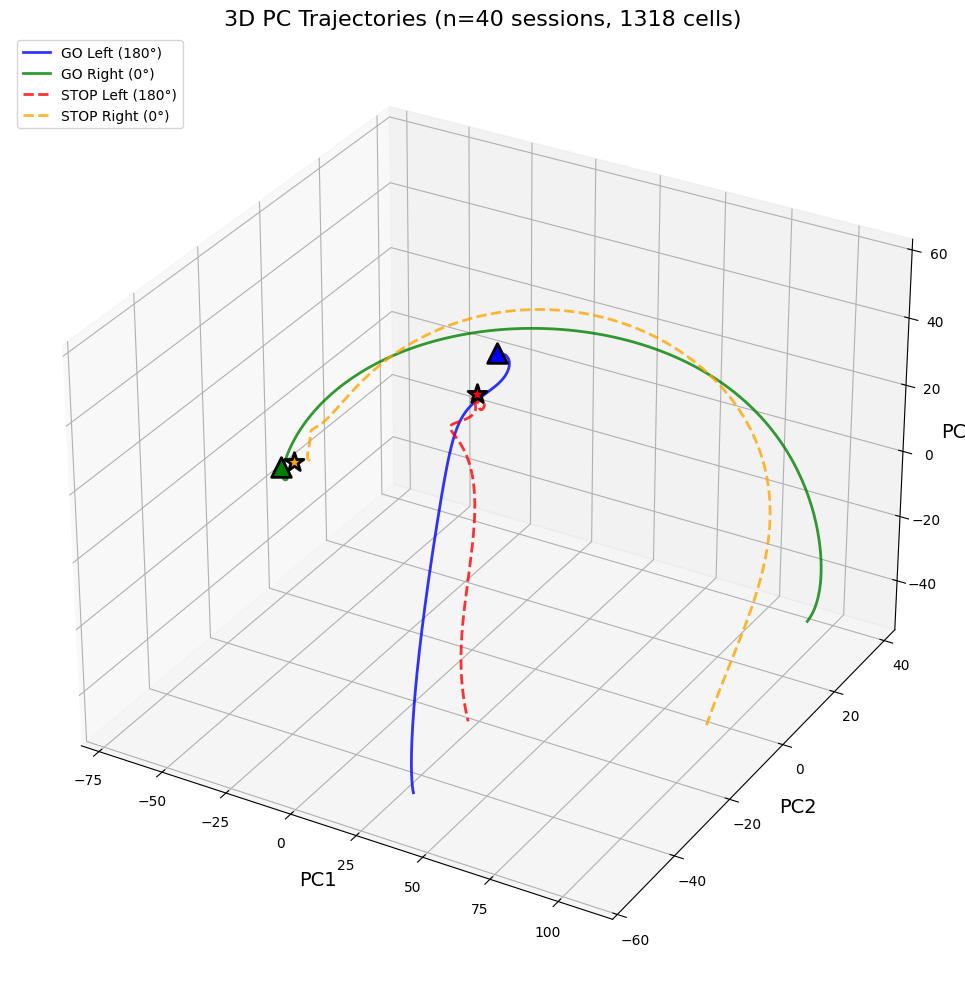

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D PC Trajectories (n=40 sessions, 1318 cells)'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>)

In [9]:
# Visualize results
analyzer.plot_3d_trajectory()

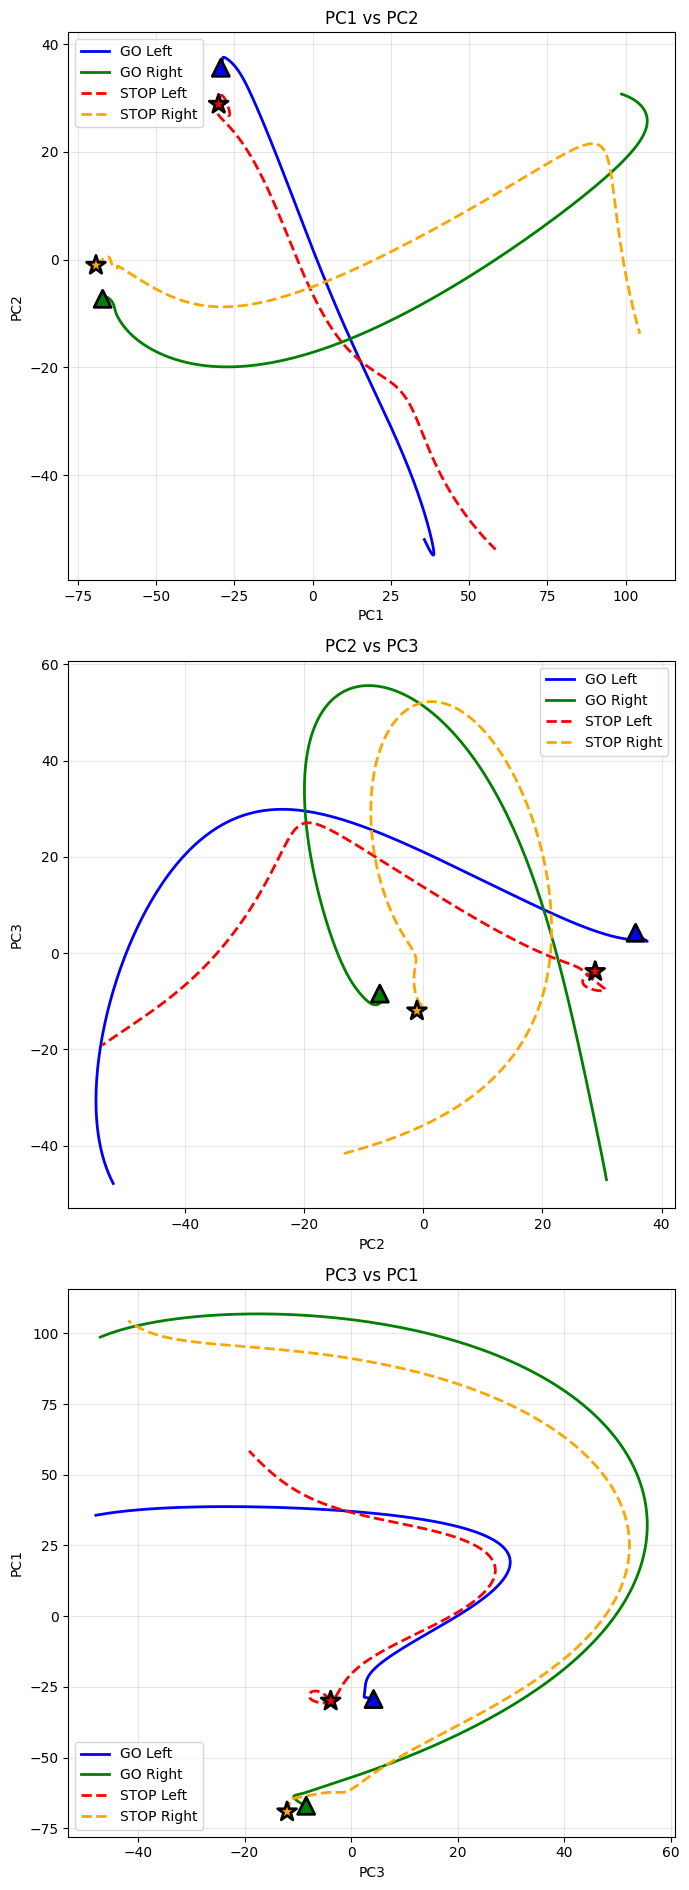

(<Figure size 700x1900 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 vs PC2'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'PC2 vs PC3'}, xlabel='PC2', ylabel='PC3'>,
        <Axes: title={'center': 'PC3 vs PC1'}, xlabel='PC3', ylabel='PC1'>],
       dtype=object))

In [10]:
# 2D projections grid
analyzer.plot_2d_grid()

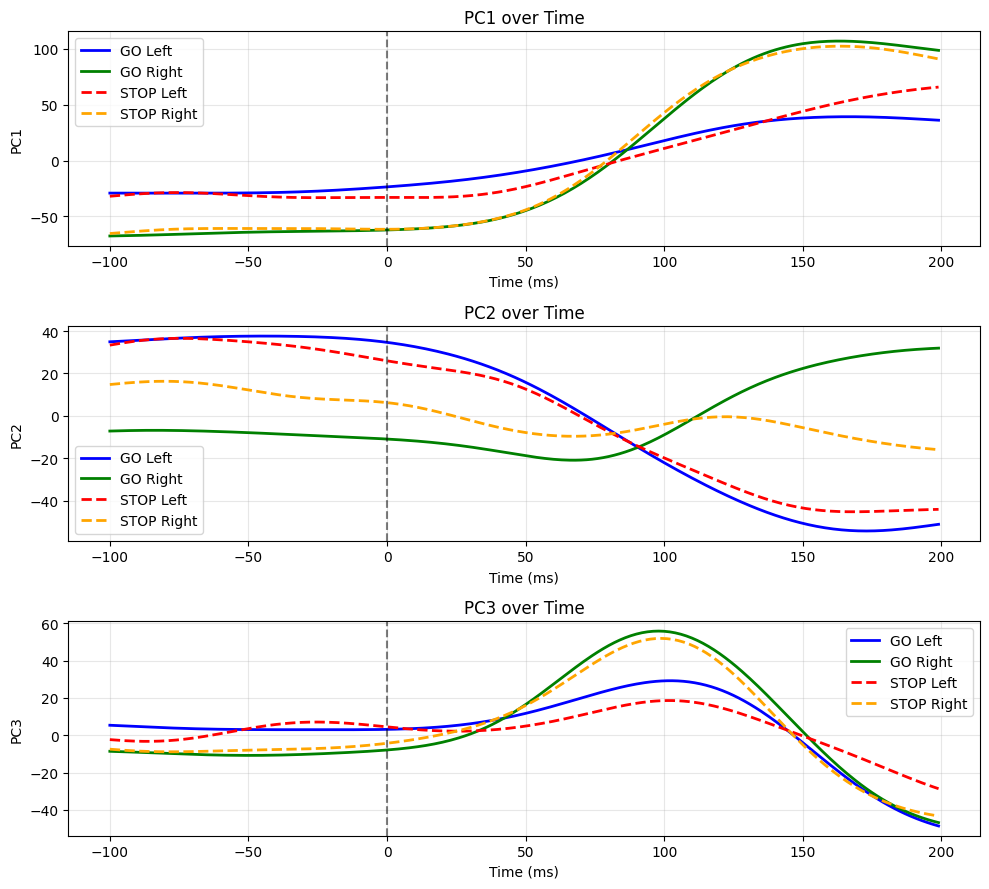

(<Figure size 1000x900 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 over Time'}, xlabel='Time (ms)', ylabel='PC1'>,
        <Axes: title={'center': 'PC2 over Time'}, xlabel='Time (ms)', ylabel='PC2'>,
        <Axes: title={'center': 'PC3 over Time'}, xlabel='Time (ms)', ylabel='PC3'>],
       dtype=object))

In [10]:
# PC time series
analyzer.plot_pc_timeseries(pcs_to_plot=[0, 1, 2])

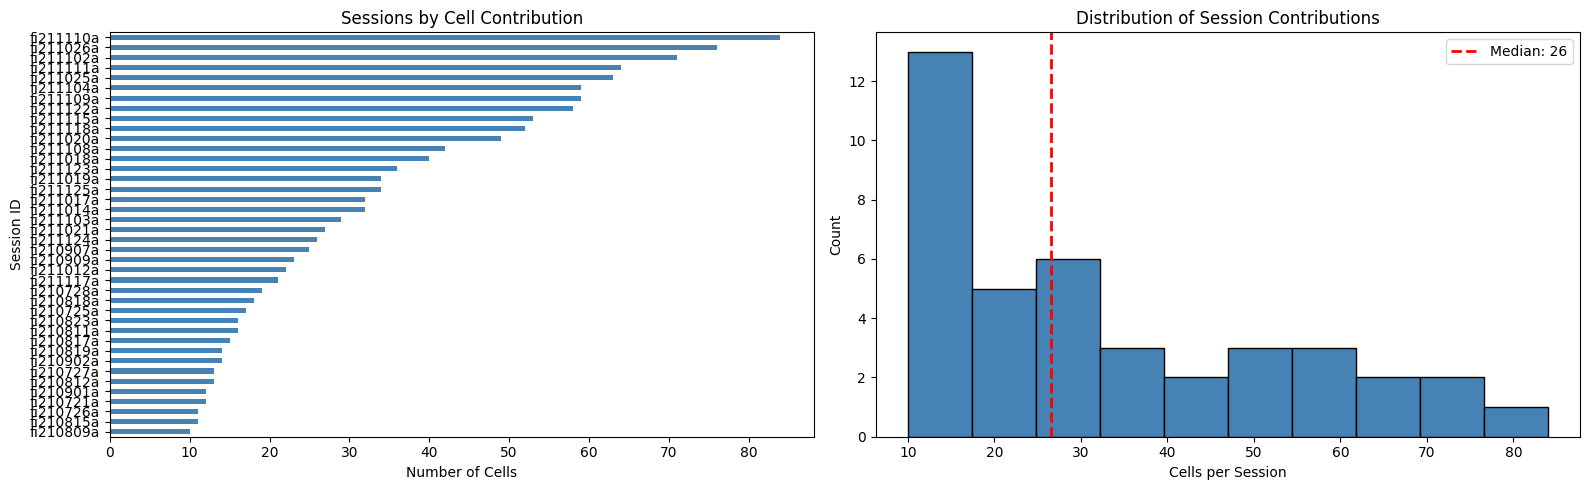

(<Figure size 1600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Sessions by Cell Contribution'}, xlabel='Number of Cells', ylabel='Session ID'>,
        <Axes: title={'center': 'Distribution of Session Contributions'}, xlabel='Cells per Session', ylabel='Count'>],
       dtype=object))

In [11]:
# Session contributions
analyzer.plot_session_contributions()

In [12]:
# Print summary
analyzer.get_summary()

MULTI-SESSION PCA ANALYSIS SUMMARY

Data Summary:
  Monkey: fiona
  Sessions analyzed: 40
  Total cells: 1322

PCA Configuration:
  Epoch: [-100, 200] ms (relative to go_cue)
  Bin size: 1 ms
  Smoothing: 25 ms
  Normalization: False
  Subtract average: False
  Components: 5

PCA Results:
  PC1: 58.78% variance
  PC2: 16.61% variance
  PC3: 11.07% variance
  PC4: 4.26% variance
  PC5: 3.15% variance
  Total: 93.87%


In [13]:
# Save results
output_dir = Path.cwd().parent / 'data' / 'PCA_data' / 'multi_session_class_test'
analyzer.save_results(output_dir)

✓ Results saved to: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_class_test


## Example 2: Custom Configuration

Customize parameters for different analyses.

In [11]:
# Custom configuration - shorter epoch, different smoothing
custom_config = {
    'epok': [-50, 300],  # Shorter epoch
    'bin_size': 1,       # Coarser bins
    'smooth_ker_size': 50,  # More smoothing
    'n_pca_components': 3,  # Fewer components
    'subtract_average': False,  # Don't subtract average
    'min_cells_per_session': 15,  # Stricter threshold
}

analyzer2 = MultiSessionPCA(custom_config)

print("Custom Configuration:")
print(f"  Epoch: {analyzer2.config['epok']} ms")
print(f"  Bin size: {analyzer2.config['bin_size']} ms")
print(f"  Smoothing: {analyzer2.config['smooth_ker_size']} ms")
print(f"  PCA components: {analyzer2.config['n_pca_components']}")
print(f"  Min cells per session: {analyzer2.config['min_cells_per_session']}")

Custom Configuration:
  Epoch: [-50, 300] ms
  Bin size: 1 ms
  Smoothing: 50 ms
  PCA components: 3
  Min cells per session: 15


In [13]:
# Run full pipeline with custom config
analyzer2.load_data(pickle_file)
analyzer2.validate_all_sessions()
analyzer2.extract_all_sessions_parallel(pickle_path=pickle_file)
analyzer2.concatenate_sessions()
analyzer2.subtract_average_PSTH()  # Will skip since subtract_average=False
analyzer2.fit_and_project()
analyzer2.get_summary()

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414
Validating sessions...
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi211018a: Valid (40 cells)
✓ fi211123a: Valid (36 cells)
✓ fi211019a: Valid (34 cells)
✓ fi211125a: Valid (34 cells)
✓ fi211014a: Valid (32 cells)
✓ fi211017a: Valid (32 cells)
✓ fi211103a: Valid (29 cells)
✓ 

Processing:   6%|▋         | 2/31 [00:08<01:42,  3.54s/it]

[1/31] ✓ fi211102a: 71 cells
[2/31] ✓ fi211025a: 63 cells


Processing:  10%|▉         | 3/31 [00:09<01:00,  2.15s/it]

[3/31] ✓ fi211104a: 59 cells


...

Processing:  97%|█████████▋| 30/31 [00:29<00:00,  2.64it/s]

[30/31] ✓ fi210811a: 16 cells


Processing: 100%|██████████| 31/31 [00:29<00:00,  1.04it/s]

[31/31] ✓ fi210817a: 15 cells


--------------------------------------------------------------------------------
✓ Extraction complete: 31/31 successful
Concatenating PSTH matrices across sessions...
✓ Concatenation complete:
  GO Left: (1212, 350)
  GO Right: (1212, 350)
  STOP Left: (1212, 350)
  STOP Right: (1212, 350)
✓ Skipping average subtraction (subtract_average=False)
✓ PCA matrix prepared: (1212, 700)
  (n_cells=1212, n_features=700)
Fitting PCA with 3 components...
✓ PCA fitted
  PC1: 55.77% variance
  PC2: 26.52% variance
  PC3: 9.92% variance
  Total: 92.20%
Projecting all conditions onto PC space...
✓ Projections complete:
  GO Left: (3, 350)
  GO Right: (3, 350)
  STOP Left: (3, 350)
  STOP Right: (3, 350)
MULTI-SESSION PCA ANALYSIS SUMMARY

Data Summary:
  Monkey: fiona
  Sessions analyzed: 31
  Total cells: 1212

PCA Configuration:
  Epoch: [-50, 300] ms (relative to go_cue)
  Bin size: 1 ms
  Smoothing: 50 ms
  Normalization: by_baseline_FR
  Subtract average: False
  Components: 3

PCA Results:
  P

## Example 3: Chain Methods for Compact Code

Most methods return `self`, allowing method chaining.

In [14]:
# One-liner pipeline (without extraction)
analyzer3 = (
    MultiSessionPCA()
    .load_data(pickle_file)
    .validate_all_sessions(verbose=False)
)

print(f"✓ Loaded and validated: {analyzer3.n_sessions} sessions")

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414
✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ Loaded and validated: 40 sessions


## Example 4: Access Intermediate Results

All intermediate data is stored as attributes.

In [15]:
# Access validation results
print("Validation DataFrame:")
print(analyzer.validation_df.head(10))

# Check invalid sessions
invalid = analyzer.validation_df[~analyzer.validation_df['is_valid']]
print(f"\nInvalid sessions: {len(invalid)}")
print(invalid[['session_id', 'reason']].head())

Validation DataFrame:
   session_id  is_valid reason  n_cells
45  fi211110a      True  Valid       84
11  fi211026a      True  Valid       76
57  fi211102a      True  Valid       71
8   fi211111a      True  Valid       64
44  fi211025a      True  Valid       63
22  fi211104a      True  Valid       59
39  fi211109a      True  Valid       59
31  fi211122a      True  Valid       58
26  fi211115a      True  Valid       53
10  fi211118a      True  Valid       52

Invalid sessions: 20
   session_id                      reason
54  fi210830a  Insufficient cells: 9 < 10
34  fi210831a  Insufficient cells: 9 < 10
13  fi210729a  Insufficient cells: 9 < 10
25  fi210822a  Insufficient cells: 9 < 10
48  fi210816a  Insufficient cells: 7 < 10


In [16]:
# Access cell-session mapping
print("Cell-Session Mapping:")
print(analyzer.cell_session_df.head())
print(f"\nCells per session:")
print(analyzer.cell_session_df['session_id'].value_counts().head())

Cell-Session Mapping:
   cell_id session_id
0     1837  fi211102a
1     1838  fi211102a
2     1840  fi211102a
3     1841  fi211102a
4     1844  fi211102a

Cells per session:
session_id
fi211110a    84
fi211026a    75
fi211102a    71
fi211111a    64
fi211025a    63
Name: count, dtype: int64


In [17]:
# Access PC projections directly
print(f"GO Left PCs shape: {analyzer.go_left_PCs.shape}")
print(f"GO Right PCs shape: {analyzer.go_right_PCs.shape}")
print(f"Time axis shape: {analyzer.time.shape}")

# Access PCA object
print(f"\nPCA explained variance: {analyzer.pca.explained_variance_ratio_}")

GO Left PCs shape: (5, 300)
GO Right PCs shape: (5, 300)
Time axis shape: (300,)

PCA explained variance: [0.58814515 0.16603111 0.11074176 0.04236913 0.03162799]


## Example 5: Save All Plots

Generate and save all visualizations without displaying.

In [18]:
# Create output directory
output_dir = Path.cwd().parent / 'data' / 'PCA_data' / 'multi_session_plots'
output_dir.mkdir(parents=True, exist_ok=True)

# Generate all plots (don't show, just save)
analyzer.plot_3d_trajectory(save_path=output_dir / '3d_trajectory.png', show=False)
analyzer.plot_2d_grid(save_path=output_dir / '2d_grid.png', show=False)
analyzer.plot_pc_timeseries(pcs_to_plot=[0, 1, 2], save_path=output_dir / 'pc_timeseries.png', show=False)
analyzer.plot_session_contributions(save_path=output_dir / 'session_contributions.png', show=False)

print(f"✓ All plots saved to: {output_dir}")

✓ Saved: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_plots/3d_trajectory.png
✓ Saved: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_plots/2d_grid.png
✓ Saved: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_plots/pc_timeseries.png
✓ Saved: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_plots/session_contributions.png
✓ All plots saved to: /Users/barak/Projects/population_analysis/data/PCA_data/multi_session_plots


## Example 6: Rolling Window Analysis Preview

Demonstrates how to use the class for rolling window PCA.

In [19]:
# Define rolling windows
window_size = 200  # ms
window_step = 50   # ms

windows = [
    [-50, 150],
    [0, 200],
    [50, 250],
    [100, 300],
]

print(f"Rolling window analysis with {len(windows)} windows:")
for i, window in enumerate(windows):
    print(f"  Window {i+1}: {window} ms")

# NOTE: Full rolling window implementation will be done separately
# This class makes it easy - just loop over windows, update config['epok'], and re-run!

Rolling window analysis with 4 windows:
  Window 1: [-50, 150] ms
  Window 2: [0, 200] ms
  Window 3: [50, 250] ms
  Window 4: [100, 300] ms


In [20]:
# Example: Analyze first window
window_config = analyzer.config.copy()
window_config['epok'] = windows[0]

window_analyzer = MultiSessionPCA(window_config)
window_analyzer.load_data(pickle_file)
window_analyzer.validate_all_sessions(verbose=False)

print(f"✓ Window 1 analyzer ready: {window_analyzer.config['epok']} ms")
print(f"  Valid sessions: {window_analyzer.n_sessions}")

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414
✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ Window 1 analyzer ready: [-50, 150] ms
  Valid sessions: 40


## Summary

The `MultiSessionPCA` class provides:

✅ **Clean workflow**: Step-by-step pipeline with clear methods  
✅ **Flexible configuration**: Easy parameter tuning  
✅ **Reusable**: Perfect for rolling window analysis  
✅ **Transparent**: All intermediate data accessible  
✅ **Convenient**: Built-in plotting and saving  

**Next steps:**
1. Implement rolling window PCA analysis
2. Add cross-validation methods
3. Add more visualization options
4. Extend to other analysis types